In [16]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()  # take environment variables from .env.

True

In [17]:
model = ChatOpenAI()
# response = model.invoke("OM NAMAH SHIVAYA")

# print(response.content)

In [18]:
class LLMState(TypedDict):
    user_input: str
    llm_response: str

In [19]:
def llm_task(state:LLMState) -> LLMState:
    # read user input from state
    user_input = state['user_input']

    # create prompt
    prompt = f"Answer the following question: {user_input}"

    # invoke llm model
    response = model.invoke(prompt)

    # store response in state
    state['llm_response'] = response.content

    return state

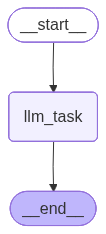

In [20]:
graph = StateGraph(LLMState)

graph.add_node("llm_task", llm_task)

graph.add_edge(START, "llm_task")
graph.add_edge("llm_task", END)

workflow = graph.compile()

workflow

In [22]:
response = workflow.invoke({"user_input": "how famous is Cricket in this world?"})
print(response['llm_response'])

Cricket is one of the most popular sports in the world, particularly in countries such as India, England, Australia, South Africa, and the West Indies. It has a massive following, with millions of fans attending matches, watching on TV, and engaging in fantasy leagues and online forums. The sport is considered a national obsession in some countries and players are often treated as celebrities. Overall, cricket is highly famous and widely followed across the globe.
